**Import Libraries**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

**Get the Data**

In [2]:
loans = pd.read_csv('loan_data.csv')

**Explore the Data**

In [19]:
loans.head()
loans.info()
loans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


**Exploratory Data Analysis**

Text(0.5, 0, 'FICO')

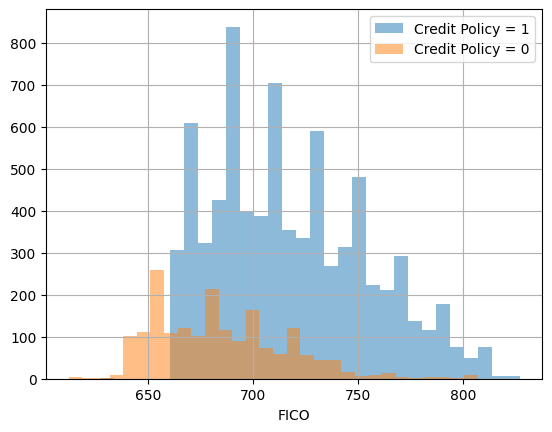

In [5]:
loans[loans['credit.policy'] == 1]['fico'].hist(alpha=0.5, bins=30, label='Credit Policy = 1')
loans[loans['credit.policy'] == 0]['fico'].hist(alpha=0.5, bins=30, label='Credit Policy = 0')
plt.legend()
plt.xlabel('FICO')

Text(0.5, 0, 'FICO')

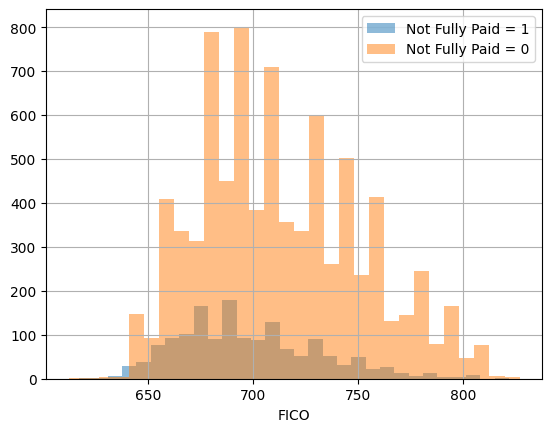

In [6]:
loans[loans['not.fully.paid'] == 1]['fico'].hist(alpha=0.5, bins=30, label='Not Fully Paid = 1')
loans[loans['not.fully.paid'] == 0]['fico'].hist(alpha=0.5, bins=30, label='Not Fully Paid = 0')
plt.legend()
plt.xlabel('FICO')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'debt_consolidation'),
  Text(1, 0, 'credit_card'),
  Text(2, 0, 'all_other'),
  Text(3, 0, 'home_improvement'),
  Text(4, 0, 'small_business'),
  Text(5, 0, 'major_purchase'),
  Text(6, 0, 'educational')])

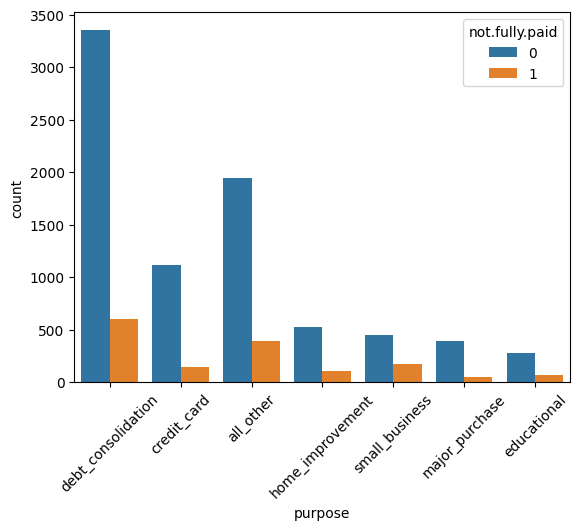

In [7]:
sns.countplot(x='purpose', hue='not.fully.paid', data=loans)
plt.xticks(rotation=45)

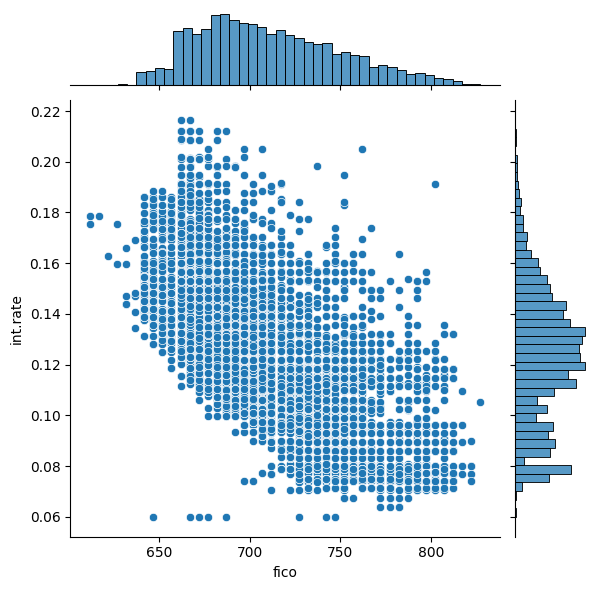

In [8]:
sns.jointplot(x='fico', y='int.rate', data=loans)

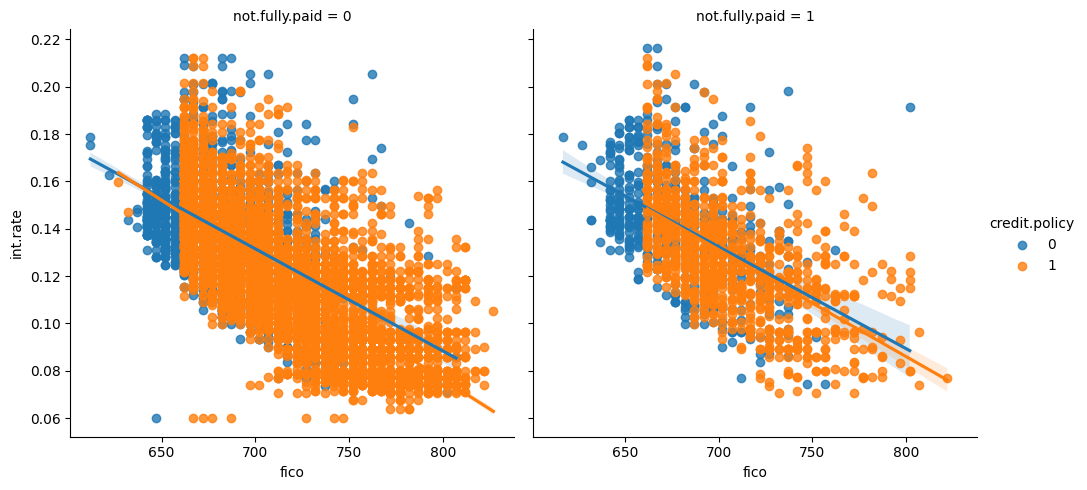

In [9]:
sns.lmplot(x='fico', y='int.rate', data=loans, hue='credit.policy', col='not.fully.paid')

**Prepare the Data**

**Convert categorical variables**

In [10]:
cat_feats = ['purpose']
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)

**Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

**Train Decision Tree**

In [12]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**Evaluate Decision Tree**

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

dtree_pred = dtree.predict(X_test)

print("Decision Tree Results:")
print(confusion_matrix(y_test, dtree_pred))
print(classification_report(y_test, dtree_pred))

Decision Tree Results:
[[1987  410]
 [ 364  113]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      2397
           1       0.22      0.24      0.23       477

    accuracy                           0.73      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.74      0.73      0.74      2874



**Train Random Fores**

In [20]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

,n_estimators,600
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Evaluate Random Forest**

In [21]:
rfc_pred = rfc.predict(X_test)

print("Random Forest Results:")
print(confusion_matrix(y_test, rfc_pred))
print(classification_report(y_test, rfc_pred))

Random Forest Results:
[[2387   10]
 [ 474    3]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      2397
           1       0.23      0.01      0.01       477

    accuracy                           0.83      2874
   macro avg       0.53      0.50      0.46      2874
weighted avg       0.73      0.83      0.76      2874



**What performed better the random forest or the decision tree?**

The Random Forest model achieved higher overall accuracy compared to the Decision Tree. 
However, the Decision Tree performed better in identifying the minority class (not fully paid loans). 
Since detecting risky borrowers is more important, the Decision Tree model may be more useful in this case.